# **Operations to be done with google drive**

In [ ]:
#@title Linking with Drive

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **Data Processing**

In [ ]:
#@title Requirements

import tensorflow as tf
import os

In [ ]:
#@title Choosing Resources

gpus = tf.config.experimental.list_physical_devices('GPU')
for gpu in gpus:
   tf.config.experimental.set_memory_growth(gpu, True)

In [ ]:
#@title Data Cleansing

import cv2
import imghdr
from matplotlib import pyplot as plt
from PIL import Image

data_dir = ['/content/drive/My Drive/Facial Emotion Recognition/Cohn-Kanade Dataset (CK+)']

# image_exts = ['jpg', 'jpeg', 'png', 'bmp']
# # print(os.listdir(data_dir[0]))
# # print(os.listdir(os.path.join(data_dir[0], 'benign')))

# '''
# img = cv2.imread(os.path.join(data_dir, 'benign', 'image_7.jpg'))
# print(img)
# print(img.shape)
# plt.imshow(img)
# plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
# '''
# for i in data_dir:
#     for image_class in os.listdir(i):
#         for image in os.listdir(os.path.join(i, image_class)):
#             image_path = os.path.join(i, image_class, image)
#             try:
#                 img = cv2.imread(image_path)    # Opening up an image (opens as numpy array)
#                 tip = imghdr.what(image_path)
#                 if tip not in image_exts:
#                     print('Image not in ext list {}'.format(image_path))
#                     os.remove(image_path)
#             except Exception as e:
#                 print('Issue with image {}'.format(image_path))

Found 2816 files belonging to 5 classes.
Batch classes:  [1 4 2 0 1 2 2 4 2 1 2 0 4 4 1 3 1 2 3 3 3 4 3 1 2 2 0 2 4 3 3 3]


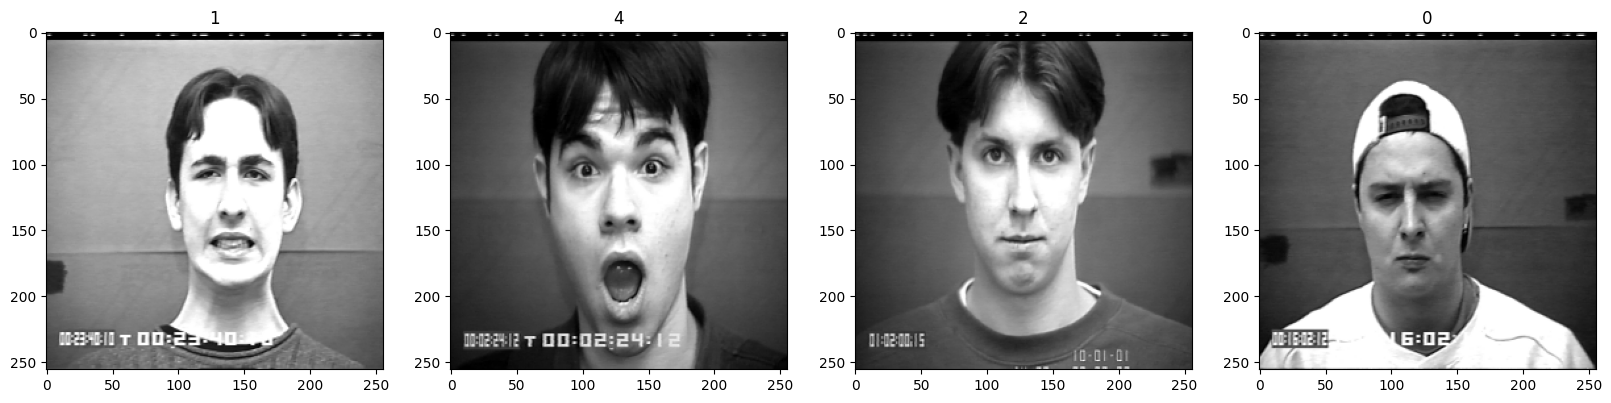

In [ ]:
#@title Creating Data Pipeline
import numpy as np

data = tf.keras.utils.image_dataset_from_directory('/content/drive/My Drive/Facial Emotion Recognition/Cohn-Kanade Dataset (CK+)', shuffle=True)     # Building data pipeline

data_iterator = data.as_numpy_iterator()        # Helps in accessing data pipeline
batch = data_iterator.next()            # Accessing data pipeline
print("Batch classes: ", batch[1])
fig, ax = plt.subplots(ncols=4, figsize=(20,20))
for idx, img in enumerate(batch[0][:4]):
    ax[idx].imshow(img.astype(int))
    ax[idx].title.set_text(batch[1][idx])

In [ ]:
#@title Preprocessing Data

''' Scaling Data '''
# Scaling Data
data = data.map(lambda x,y: (x/255, y))
data.as_numpy_iterator().next()[0].max()


''' Splitting Data '''
train_size = int(len(data)*.7)
val_size = int(len(data)*.1)+1
test_size = int(len(data)*.2)+1

train = data.take(train_size)
val = data.take(val_size)
test = data.take(test_size)

print(train_size, "+", test_size, "+", val_size, "=", len(data))

61 + 18 + 9 = 88


In [ ]:
#@title Assigning weights to classes
from sklearn.utils.class_weight import compute_class_weight
from tqdm import tqdm

# images = []
labels = []
# data = []
for batch in tqdm(train.as_numpy_iterator()):
    X1, y1 = batch
    # images.extend(list(X1))
    labels.extend(list(y1))

# data = np.array(images)
labels = np.array(labels)
# print(data.shape)
print(labels)

# Calculate class weights using scikit-learn's compute_class_weight function
class_weights = compute_class_weight(class_weight = 'balanced', classes = np.unique(labels), y = labels)
class_weights = dict(zip(np.unique(labels), class_weights))

61it [05:40,  5.58s/it]

[3 1 3 ... 3 4 2]


# **Deep Learning Models Creation, Training, Evaluating, Saving, Performance Graph etc.**

In [ ]:
#@title Deep Models MobileNet variants

import keras.backend as K
from tensorflow.keras import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPool2D, Dense, Flatten, Dropout, AveragePooling2D, Concatenate, GlobalAveragePooling2D, BatchNormalization, ReLU, Add, SeparableConv2D, Lambda, Activation, Reshape, DepthwiseConv2D
from tensorflow.keras.applications import MobileNetV2, MobileNetV3Small, MobileNetV3Large
from tensorflow.keras.layers import Layer
import numpy as np
import math


def inception_block(x, filters):
    conv1x1 = Conv2D(filters=filters[0], kernel_size=1, padding='same', activation='relu')(x)

    conv3x3_reduce = Conv2D(filters=filters[1], kernel_size=1, padding='same', activation='relu')(x)
    conv3x3 = Conv2D(filters=filters[2], kernel_size=3, padding='same', activation='relu')(conv3x3_reduce)

    conv5x5_reduce = Conv2D(filters=filters[3], kernel_size=1, padding='same', activation='relu')(x)
    conv5x5 = Conv2D(filters=filters[4], kernel_size=5, padding='same', activation='relu')(conv5x5_reduce)

    maxpool = MaxPool2D(pool_size=(3, 3), strides=(1, 1), padding='same')(x)
    maxpool_proj = Conv2D(filters=filters[5], kernel_size=1, padding='same', activation='relu')(maxpool)

    output = Concatenate(axis=-1)([conv1x1, conv3x3, conv5x5, maxpool_proj])
    return output


class ReParamSwish1Layer(Layer):
    def __init__(self, **kwargs):
        super(ReParamSwish1Layer, self).__init__(**kwargs)

    def fuzzy_rank(self, CF):
        R_L = ((CF - (-10) - (-9.5))/(1 + tf.math.exp(-(0.5)*(CF - 10 - (-9.5))))) + (-10)       # Re-parameterized Swish-1 Function
        return R_L

    def call(self, inputs):
        predictions = self.fuzzy_rank(inputs)
        return predictions


def mobilenetv2(img_shape, n_classes, input):
    mobilenet = MobileNetV2(input_shape=img_shape, include_top=False, weights='imagenet')
    mobilenet.trainable = True

    x = tf.image.sobel_edges(input)
    sobel_x = x[:, :, :, :, 0]  # Sobel edges in x-direction
    sobel_y = x[:, :, :, :, 1]  # Sobel edges in y-direction

    # Concatenate Sobel edges along the channel axis
    sobel_combined = tf.sqrt(tf.square(sobel_x) + tf.square(sobel_y))
    x = mobilenet(sobel_combined, training=True)
    x = Conv2D(1248, (3, 3), activation='relu', padding='same')(x)
    x = GlobalAveragePooling2D()(x)
    x = Dropout(rate = 0.2)(x)

    x = Dense(256, activation='relu')(x)
    output = Dense(n_classes, activation='softmax')(x)

    model = Model(input, output)
    return model

def mobilenetv3small(img_shape, n_classes, input):
    mobilenet = MobileNetV3Small(input_shape=img_shape, include_top=False, weights='imagenet')
    mobilenet.trainable = True

    x = tf.nn.local_response_normalization(input, depth_radius=5, bias=1.0, alpha=0.001, beta=0.75)
    x = mobilenet(x, training=True)
    x = Conv2D(1248, (3, 3), activation='relu', padding='same')(x)
    x = GlobalAveragePooling2D()(x)
    x = Dropout(rate = 0.2)(x)

    x = Dense(256, activation='relu')(x)
    output = Dense(n_classes, activation='softmax')(x)

    model = Model(input, output)
    return model



def mobilenetv3large(img_shape, n_classes, input):
    mobilenet = MobileNetV3Large(input_shape=img_shape, include_top=False, weights='imagenet')
    mobilenet.trainable = True

    x = mobilenet(input, training=True)
    x = Conv2D(1248, (3, 3), activation='relu', padding='same')(x)
    x = GlobalAveragePooling2D()(x)
    x = Dropout(rate = 0.2)(x)

    x = Dense(256, activation='relu')(x)
    output = Dense(n_classes, activation='softmax')(x)

    model = Model(input, output)
    return model


def mobilenet(input_shape, n_classes):

    input = Input(input_shape)

    base_model1 = mobilenetv2(input_shape, n_classes, input)
    base_model2 = mobilenetv3small(input_shape, n_classes, input)
    base_model3 = mobilenetv3large(input_shape, n_classes, input)

    layer1 = base_model1.layers[-5]
    fusion_layer1 = layer1.output

    layer2 = base_model2.layers[-5]
    fusion_layer2 = layer2.output

    layer3 = base_model3.layers[-5]
    fusion_layer3 = layer3.output

    new_layer_1 = ReParamSwish1Layer()
    new_layer_2 = ReParamSwish1Layer()
    new_layer_3 = ReParamSwish1Layer()

    r1 = new_layer_1(fusion_layer1)
    r1 = inception_block(r1, [64, 96, 128, 16, 32, 32])
    r2 = new_layer_2(fusion_layer2)
    r2 = inception_block(r2, [64, 96, 128, 16, 32, 32])
    r3 = new_layer_3(fusion_layer3)
    r3 = inception_block(r3, [64, 96, 128, 16, 32, 32])
    x = Add()([r1, r2, r3]) # tf.sqrt(tf.square(fusion_layer1) + tf.square(fusion_layer2) + tf.square(fusion_layer3))
    x = GlobalAveragePooling2D()(x)
    x = Dropout(rate = 0.2)(x)

    output = Dense(n_classes, activation='softmax')(x)

    model = Model(inputs=[input], outputs=[output])
    return model



input_shape = (256, 256, 3)
n_classes = 7

from keras.optimizers import SGD
opt = SGD(learning_rate=0.1)

model = mobilenet(input_shape, n_classes)
model.compile('Adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

9406464/9406464 [==============================] - 0s 0us/step


4334752/4334752 [==============================] - 0s 0us/step


12683000/12683000 [==============================] - 0s 0us/step
Model: "model_3"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 256, 256, 3)]        0         []                            
                                                                                                  
 tf.compat.v1.shape (TFOpLa  (4,)                         0         ['input_1[0][0]']             
 mbda)                                                                                            
                                                                                                  
 tf.__operators__.getitem (  ()                           0         ['tf.compat.v1.shape[0][0]']  
 SlicingOpLambda)                                                                                 
                           

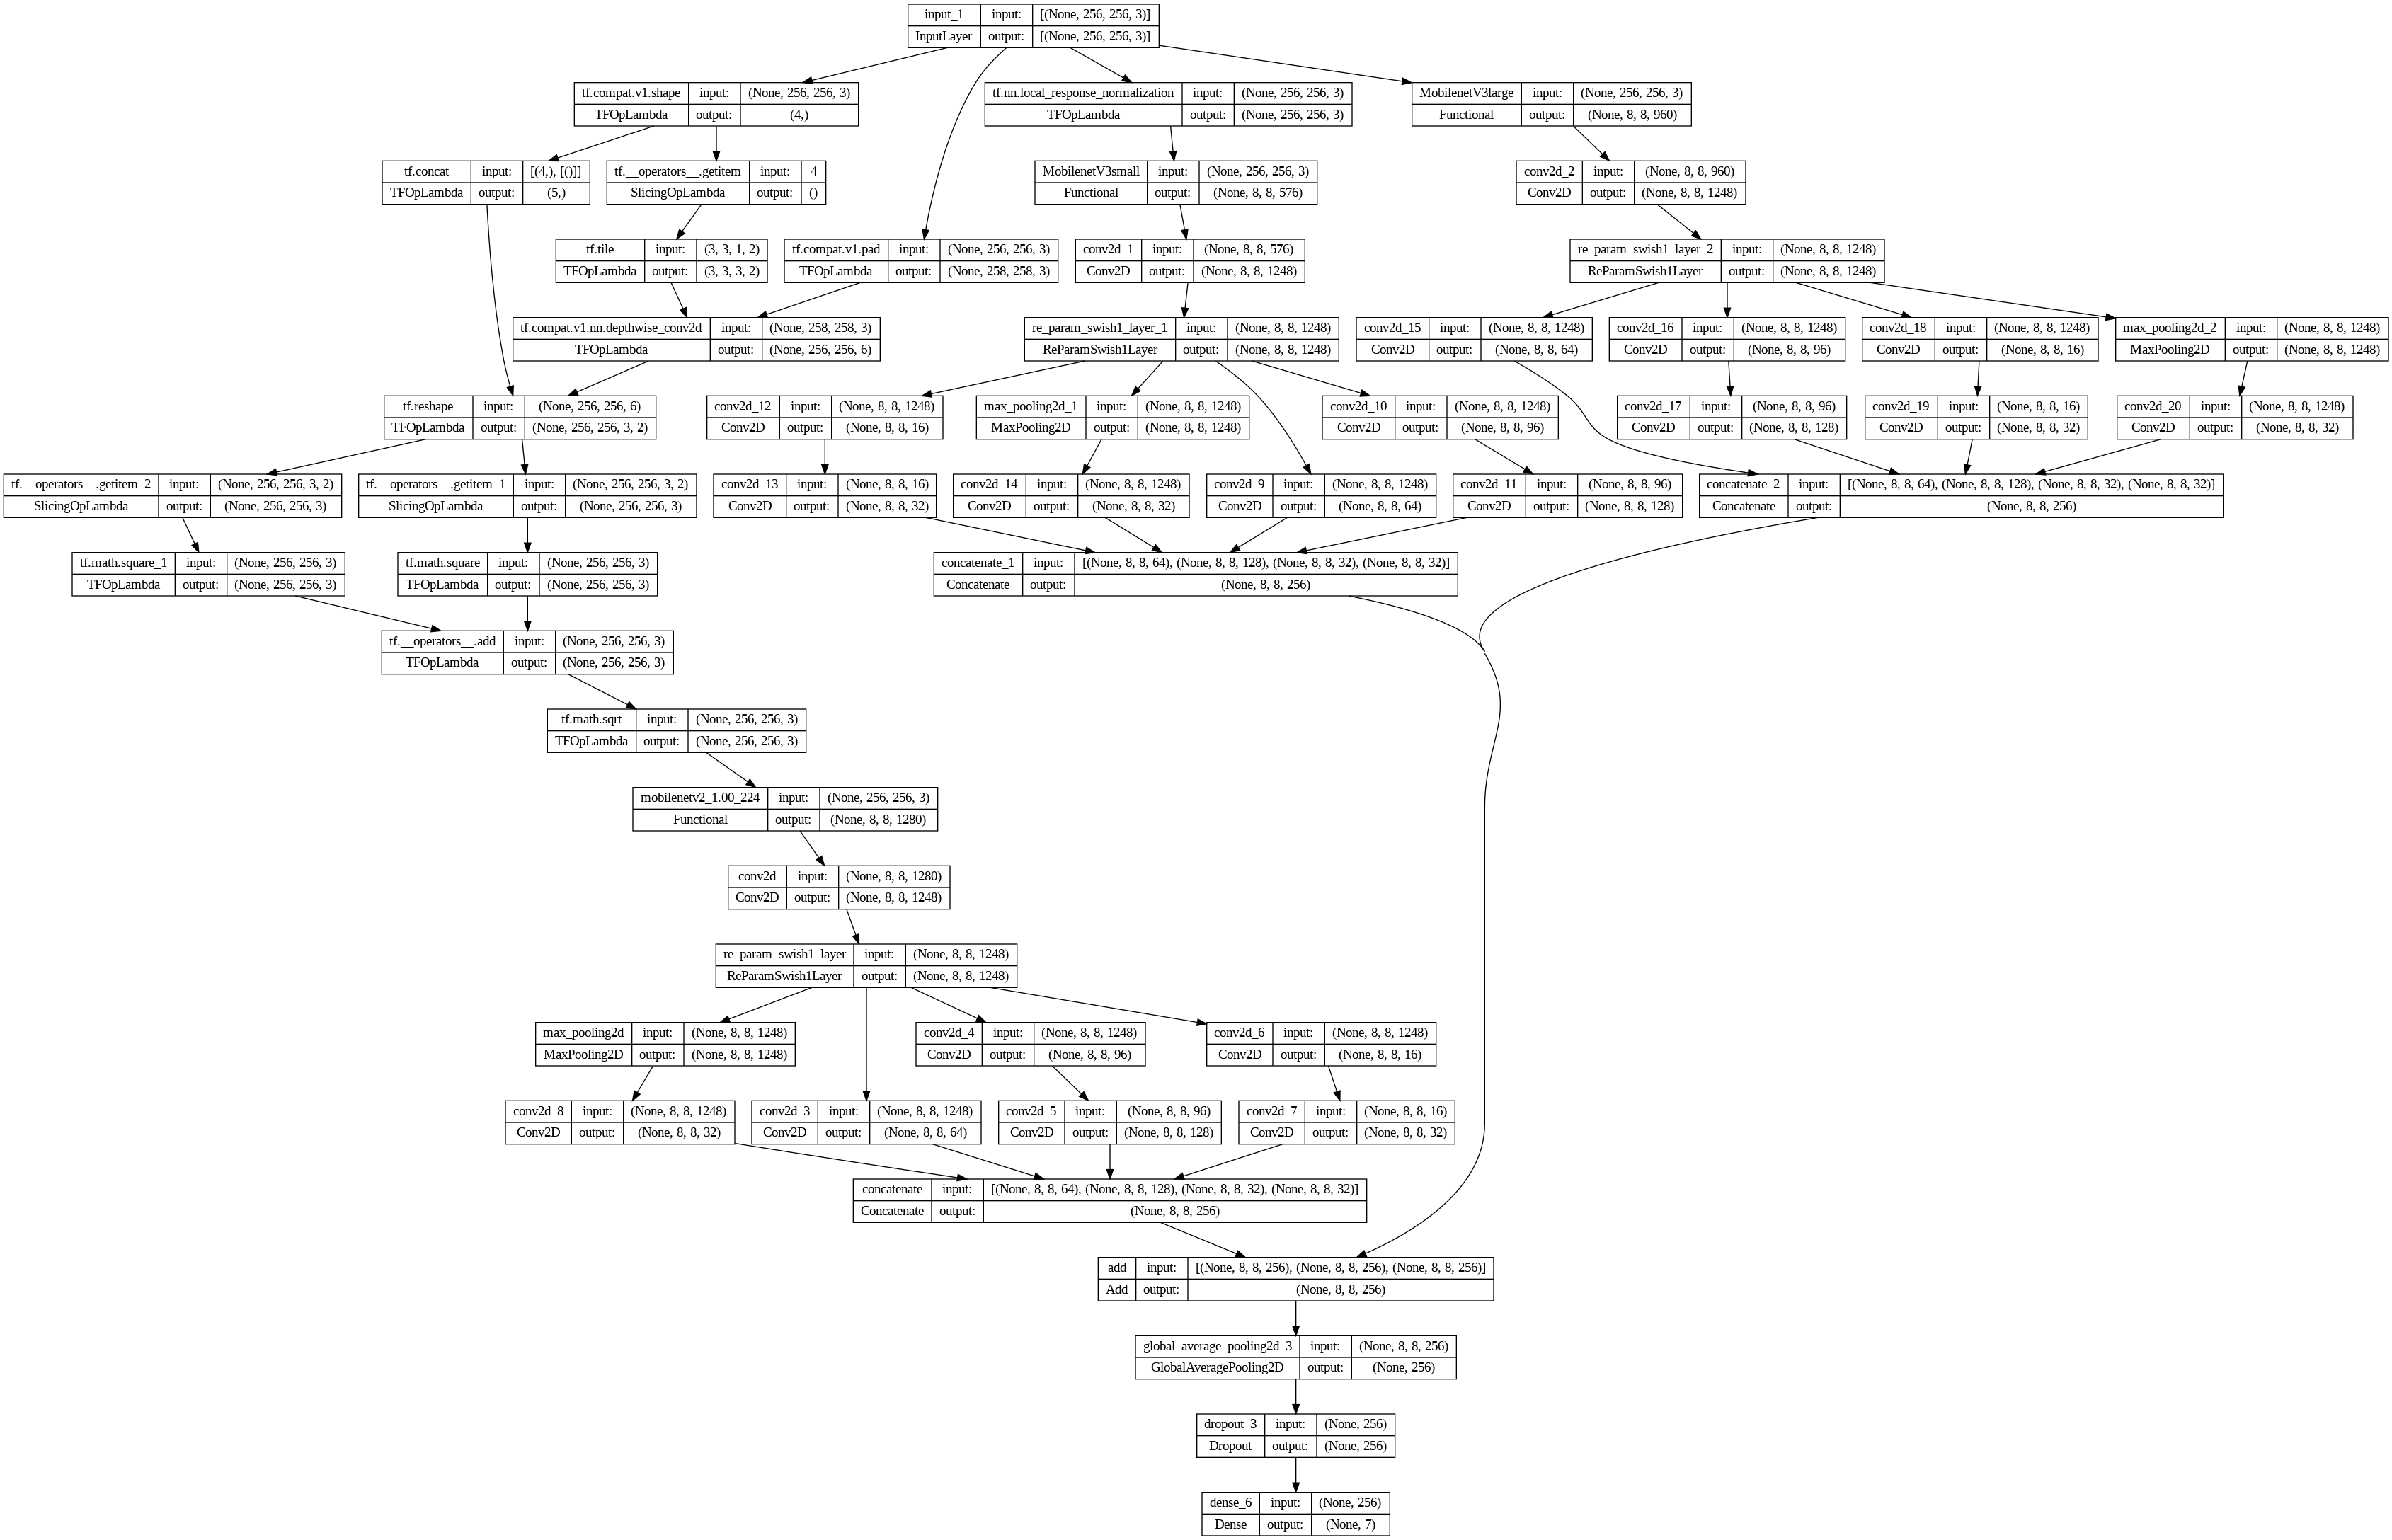

In [ ]:
#@title Plotting the Model

tf.keras.utils.plot_model(
    model,
    to_file='/content/drive/My Drive/Facial Emotion Recognition/models/siamese_swish1_hybrid_mobilenet_ck.png',
    show_shapes=True,
    show_layer_names=True,
    rankdir='TB',
    expand_nested=False,
    dpi=96,
)

In [ ]:
#@title Training the Models

# Train
logdir='/content/drive/My Drive/Facial Emotion Recognition/logs'
tensorboard_callback1 = tf.keras.callbacks.TensorBoard(log_dir=logdir)
tensorboard_callback2 = tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', min_delta=0.0010, patience=5, verbose=1, mode='max', restore_best_weights=True, start_from_epoch=0)
hist = model.fit(train, class_weight=class_weights, validation_data=val, epochs=60, callbacks=[tensorboard_callback1, tensorboard_callback2])
print(hist.history)

Epoch 1/60
61/61 [==============================] - 35s 525ms/step - loss: 0.0223 - accuracy: 0.9928 - val_loss: 0.0446 - val_accuracy: 0.9896
Epoch 2/60
61/61 [==============================] - 35s 542ms/step - loss: 0.1250 - accuracy: 0.9626 - val_loss: 0.1030 - val_accuracy: 0.9722
Epoch 3/60
61/61 [==============================] - 34s 528ms/step - loss: 0.1871 - accuracy: 0.9442 - val_loss: 0.1430 - val_accuracy: 0.9618
Epoch 4/60
61/61 [==============================] - 33s 515ms/step - loss: 0.1737 - accuracy: 0.9472 - val_loss: 0.0589 - val_accuracy: 0.9792
Epoch 5/60
61/61 [==============================] - 35s 548ms/step - loss: 0.0651 - accuracy: 0.9805 - val_loss: 0.0424 - val_accuracy: 0.9792
Epoch 6/60
61/61 [==============================] - 33s 518ms/step - loss: 0.0319 - accuracy: 0.9882 - val_loss: 0.0278 - val_accuracy: 0.9965
Epoch 7/60
61/61 [==============================] - 34s 543ms/step - loss: 0.0333 - accuracy: 0.9928 - val_loss: 0.0455 - val_accuracy: 0.9826

Precision:0.9979209899902344, Recall:1.0, Accuracy (Binary):0.2586805522441864, Accuracy (sparse_categorical):[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1.]
Confusion Matrix for Model 1: 
 [[ 4  0  0  0  0]
 [ 0  2  0  0  0]
 [ 0  0 17  0  0]
 [ 0  0  0  5  0]
 [ 0  0  0  0  4]]


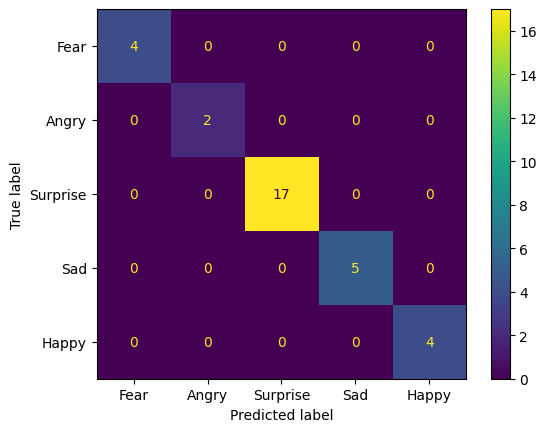

For Test Dataset: 
Precision:0.9979209899902344, Recall:1.0, Accuracy (Binary):0.2586805522441864
Confusion Matrix for Xception on Test Dataset: 
 [[ 95   0   0   1   0]
 [  0  54   0   0   0]
 [  0   0 195   0   0]
 [  0   0   0 124   0]
 [  0   0   0   0 107]]


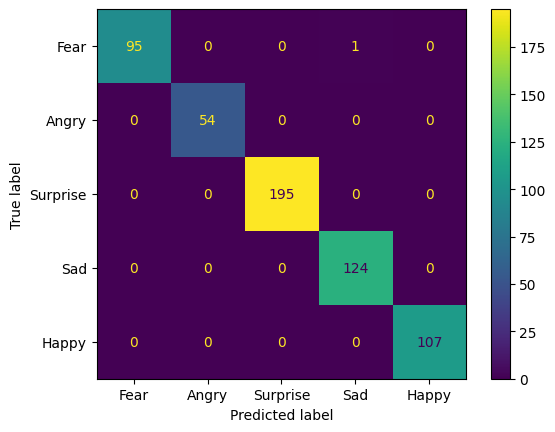

In [ ]:
#@title Evaluating the Models

''' Evaluation '''
from tensorflow.keras.metrics import Precision, Recall, BinaryAccuracy, sparse_categorical_accuracy
from sklearn.metrics import *

loss, results = model.evaluate(test, batch_size=328, callbacks=[tensorboard_callback1, tensorboard_callback2])
print("Result : \n", results)
print("Loss: \n", loss)

''' Model '''
print("For Model: ")
pre = Precision()
re = Recall()
acc = BinaryAccuracy()
labels = []
predicts = []
pre1 = Precision()
re1 = Recall()
acc1 = BinaryAccuracy()
for batch1 in test.as_numpy_iterator():
    X1, y1 = batch1
    labels.extend(list(y1))
    yhat1 = model.predict(X1, verbose=0)
    max = a = 0
    arr = np.ones(yhat1.shape[0])*-1
    for i in yhat1:
        max = np.argmax(i)
        arr[a] = max
        a+=1
    predicts.extend(list(arr))
    pre1.update_state(y1, arr)
    re1.update_state(y1, arr)
    acc1.update_state(y1, arr)
acc11 = sparse_categorical_accuracy(y1, yhat1)
assert acc11.shape == (y1.shape[0],)
print(f'Precision:{pre1.result().numpy()}, Recall:{re1.result().numpy()}, Accuracy (Binary):{acc1.result().numpy()}, Accuracy (sparse_categorical):{acc11.numpy()}')
matrix = confusion_matrix(y1, arr)
print("Confusion Matrix for Model 1: \n", matrix)
display = ConfusionMatrixDisplay(confusion_matrix = matrix, display_labels = os.listdir(data_dir[0]))
display.plot()
plt.show()

print("For Test Dataset: ")
pre.update_state(labels, predicts)
re.update_state(labels, predicts)
acc.update_state(labels, predicts)
print(f'Precision:{pre.result().numpy()}, Recall:{re.result().numpy()}, Accuracy (Binary):{acc.result().numpy()}')
matrix = confusion_matrix(labels, predicts)
print("Confusion Matrix for Xception on Test Dataset: \n", matrix)
display = ConfusionMatrixDisplay(confusion_matrix = matrix, display_labels = os.listdir(data_dir[0]))
display.plot()
plt.show()

In [ ]:
#@title Saving the Models and their Histories

import pickle


# Saving the Models

model.save('/content/drive/My Drive/Facial Emotion Recognition/models/siamese-swish1-hybrid-mobilenet-ck')  # Cannot save in .h5 or .hdf5 format as two models may have layers with same name that is not allowed


# Saving the Model Histories

with open(os.path.join(logdir+'/history.pkl'), 'wb') as file:
    pickle.dump(hist, file)

In [ ]:
#@title Re-Loading the Models and their Histories

import pickle
from tensorflow.keras.models import load_model


logdir='/content/drive/My Drive/Facial Emotion Recognition/logs'
# Loading the Models

model1 = load_model('/content/drive/My Drive/Facial Emotion Recognition/models/siamese-hybrid-mobilenet-ck')


# Loading the Model Histories

with open(os.path.join(logdir+'/history.pkl'), 'rb') as file:
    hist1 = pickle.load(file)

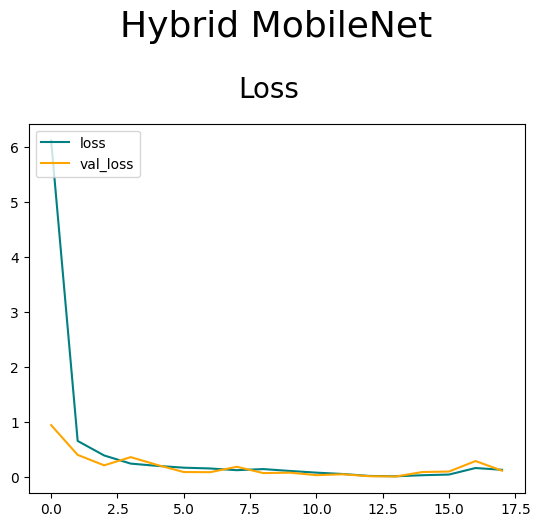

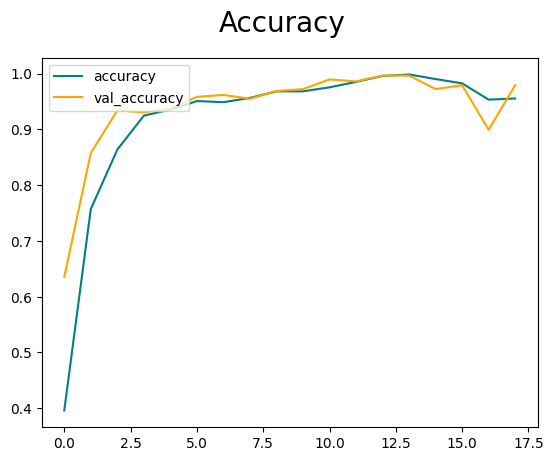

In [ ]:
#@title Performance Graphs

import matplotlib.pyplot as plt

''' Model '''
# Loss
fig = plt.figure()
plt.title("Hybrid MobileNet\n\n", loc='center', fontsize=26)
plt.plot(hist.history['loss'], color='teal', label='loss')
plt.plot(hist.history['val_loss'], color='orange', label='val_loss')
fig.suptitle('Loss', fontsize=20)
plt.legend(loc="upper left")
plt.show()

# Accuracy
fig = plt.figure()
plt.plot(hist.history['accuracy'], color='teal', label='accuracy')
plt.plot(hist.history['val_accuracy'], color='orange', label='val_accuracy')
fig.suptitle('Accuracy', fontsize=20)
plt.legend(loc="upper left")
plt.show()

In [ ]:
#@title ROC-AUC Curves

import pandas as pd
import numpy as np
from sklearn.metrics import *
import math, os
from sklearn.preprocessing import label_binarize

#ROC-AUC
from sklearn.metrics import roc_curve,auc
import matplotlib.pyplot as plt
def plot_roc(val_label,decision_val, caption='ROC Curve'):
    num_classes=np.unique(val_label).shape[0]
    classes = []
    for i in range(num_classes):
        classes.append(i)
    plt.figure()
    decision_val = label_binarize(decision_val, classes=classes)

    if num_classes!=2:
        # Compute ROC curve and ROC area for each class
        fpr = dict()
        tpr = dict()
        roc_auc = dict()
        for i in range(num_classes):
            y_val = label_binarize(val_label, classes=classes)
            fpr[i], tpr[i], _ = roc_curve(y_val[:, i], decision_val[:, i])
            roc_auc[i] = auc(fpr[i], tpr[i])
        for i in range(num_classes):
            plt.plot(fpr[i], tpr[i], label='ROC curve of class {0} (area = {1:0.2f})'
                                           ''.format(i+1, roc_auc[i]))
    else:
        fpr,tpr,_ = roc_curve(val_label,decision_val, pos_label=1)
        roc_auc = auc(fpr,tpr)*100
        plt.plot(fpr,tpr,label='ROC curve (AUC=%0.2f)'%roc_auc)

    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(caption)
    plt.legend(loc="lower right",  bbox_to_anchor=(1, 0.5))
    plt.savefig(str(len(classes))+'.png',dpi=300)

def predicting(ensemble_prob):
    prediction = np.zeros((ensemble_prob.shape[0],))
    for i in range(ensemble_prob.shape[0]):
        temp = ensemble_prob[i]
        t = np.where(temp == np.max(temp))[0][0]
        prediction[i] = t
    return prediction

def metrics(labels, predictions, classes, display_label):
    print("Classification Report:")
    print("Labels : ",labels.shape, '\nPredictions : ', predictions.shape)
    print(classification_report(labels, predictions, target_names = classes, digits = 4))
    matrix = confusion_matrix(labels, predictions)
    print("Confusion matrix:")
    print(matrix)
    plt.figure()
    display = ConfusionMatrixDisplay(confusion_matrix = matrix, display_labels = display_label)
    display.plot()
    plt.xticks(rotation=50)
    plt.show()
    print("\nClasswise Accuracy :{}".format(matrix.diagonal()/matrix.sum(axis = 1)))
    print("\nBalanced Accuracy Score: ",balanced_accuracy_score(labels,predictions))

For Model : 
Classification Report:
Labels :  (576,) 
Predictions :  (576,)
              precision    recall  f1-score   support

           1     1.0000    1.0000    1.0000        93
           2     0.9655    1.0000    0.9825        56
           3     1.0000    0.9950    0.9975       200
           4     1.0000    1.0000    1.0000       125
           5     0.9901    0.9804    0.9852       102

    accuracy                         0.9948       576
   macro avg     0.9911    0.9951    0.9930       576
weighted avg     0.9949    0.9948    0.9948       576

Confusion matrix:
[[ 93   0   0   0   0]
 [  0  56   0   0   0]
 [  0   0 199   0   1]
 [  0   0   0 125   0]
 [  0   2   0   0 100]]


<Figure size 640x480 with 0 Axes>

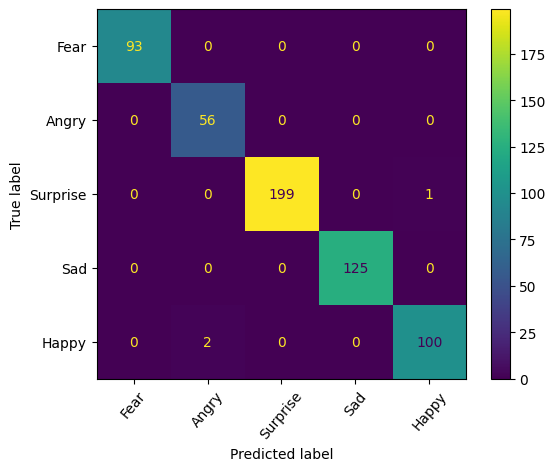


Classwise Accuracy :[1.         1.         0.995      1.         0.98039216]

Balanced Accuracy Score:  0.995078431372549
Accuracy[0.9948] Precision[0.9911] Recall[0.9951] F1[0.9930] ]
________________________________________________________________


Overall Accuracy[0.9948] Overall Precision[0.9911] Overall Recall[0.9951] Overall F1[0.9930]


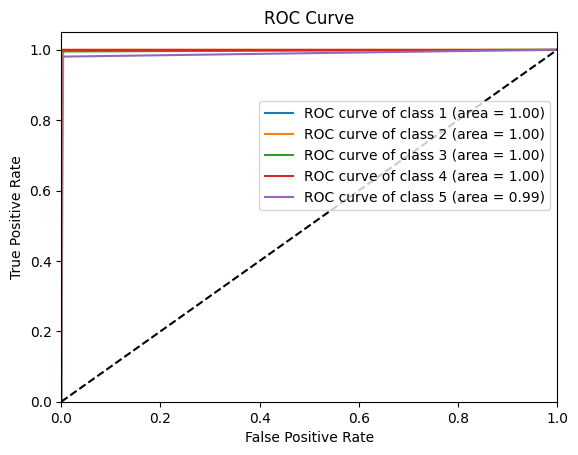

In [ ]:
#@title Precision, Recall and Accuracy of the Models with respect to test dataset

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

labels = []
p = []
p1 = []
for batch1 in test.as_numpy_iterator():
    X1, y1 = batch1
    labels.extend(list(y1))
    yhat = model.predict(X1, verbose=0)
    max = 0
    for i in yhat:
        max = np.argmax(i)
        p.append(max)
        p1.append(i)

labels = np.asarray(labels)
p = np.asarray(p)

# print("Model : ", end="")
# for i in p:
#     print(i, end=" ")

import csv
fp = open("/content/drive/My Drive/Facial Emotion Recognition/csv/siamese_hybrid_mobilenet_ck.csv",'w+',newline = '')
writer = csv.writer(fp)
for i in p1:
    writer.writerow([i[0], i[1], i[2], i[3], i[4]])
fp.close()

fp = open("/content/drive/My Drive/Facial Emotion Recognition/csv/labels_fusion_ck.csv",'w+',newline = '')
writer = csv.writer(fp)
for i in labels:
    writer.writerow([i])
fp.close()

print("For Model : ")
metrics(labels, p,  list(map(str, range(1, 6))), os.listdir(data_dir[0]))
plot_roc(labels, p)

avg_acc_list = []
avg_precision_list = []
avg_recall_list = []
avg_f1_list = []

acc_fold = accuracy_score(labels, p)
avg_acc_list.append(acc_fold)
precision_fold = precision_score(labels, p, average='macro')
avg_precision_list.append(precision_fold)
recall_fold = recall_score(labels, p, average='macro')
avg_recall_list.append(recall_fold)
f1_fold  = f1_score(labels, p, average='macro')
avg_f1_list.append(f1_fold)

print('Accuracy[{:.4f}] Precision[{:.4f}] Recall[{:.4f}] F1[{:.4f}] ]'.format(acc_fold, precision_fold, recall_fold, f1_fold ))
print('________________________________________________________________')

avg_acc = np.asarray(avg_acc_list)
avg_pre = np.asarray(avg_precision_list)
avg_recall = np.asarray(avg_recall_list)
avg_f1 = np.asarray(avg_f1_list)
print("\n")
print('Overall Accuracy[{:.4f}] Overall Precision[{:.4f}] Overall Recall[{:.4f}] Overall F1[{:.4f}]'.format(np.mean(avg_acc), np.mean(avg_pre), np.mean(avg_recall), np.mean(avg_f1)))